In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
# from torch.autograd import Variable 안쓰는 것
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
# 변경 전
# from tqdm import tqdm_notebook as tqdm
# 변경
from tqdm.notebook import tqdm
import random
import time
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
import shutil
shutil.unpack_archive('dogs-vs-cats_ver2.zip', 'dogs-vs-cats_ver2/')

In [5]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [6]:
cat_directory = r'/content/dogs-vs-cats_ver2/dogs-vs-cats_ver2/Cat'
dog_directory = r'/content/dogs-vs-cats_ver2/dogs-vs-cats_ver2/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)

N_TEST = 20

train_images_filepaths = correct_images_filepaths[:5000]
val_images_filepaths = correct_images_filepaths[5000:-N_TEST]
test_images_filepaths = correct_images_filepaths[-N_TEST:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

5000 980 20


In [7]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0

        return img_transformed, label

In [8]:
size = 256
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [9]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [10]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDataset(test_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
1


In [11]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 0, 1])


In [12]:
class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [13]:
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [18]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [14]:
!pip install torchinfo
from torchinfo import summary
summary(model, input_size=(1, 3, 256, 256))

# torchsummary는 코랩에 기본 설치돼 있지 않고 유지보수도 끊겼습니다.
# 후속인 torchinfo를 쓰는데, 입력 크기에 배치 차원(맨 앞 1)을 넣어야 한다는 점이 다릅니다.

# from torchsummary import summary
# summary(model, input_size=(3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 2]                    --
├─Sequential: 1-1                        [1, 256, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 63, 63]           23,296
│    └─ReLU: 2-2                         [1, 64, 63, 63]           --
│    └─MaxPool2d: 2-3                    [1, 64, 31, 31]           --
│    └─Conv2d: 2-4                       [1, 192, 31, 31]          307,392
│    └─ReLU: 2-5                         [1, 192, 31, 31]          --
│    └─MaxPool2d: 2-6                    [1, 192, 15, 15]          --
│    └─Conv2d: 2-7                       [1, 384, 15, 15]          663,936
│    └─ReLU: 2-8                         [1, 384, 15, 15]          --
│    └─Conv2d: 2-9                       [1, 256, 15, 15]          884,992
│    └─ReLU: 2-10                        [1, 256, 15, 15]          --
│    └─Conv2d: 2-11                      [1, 256, 15, 15]         

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    # 기록 저장 추가
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

            # 기록 저장
            history[phase + '_loss'].append(epoch_loss)
            history[phase + '_acc'].append(epoch_acc)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # val 정확도가 최고일 때 가중치 저장
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), '/content/drive/MyDrive/alexnet_best.pth')

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:.4f}'.format(best_acc))

    return model, history

In [19]:
num_epoch = 30
model, history = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/30
--------------------


  0%|          | 0/157 [00:00<?, ?it/s]

train Loss: 0.6933 Acc: 0.4940


  0%|          | 0/31 [00:00<?, ?it/s]

val Loss: 0.6929 Acc: 0.4969
Epoch 2/30
--------------------


...

val Loss: 0.5171 Acc: 0.7602
Epoch 30/30
--------------------


  0%|          | 0/157 [00:00<?, ?it/s]

train Loss: 0.5385 Acc: 0.7372


  0%|          | 0/31 [00:00<?, ?it/s]

val Loss: 0.5654 Acc: 0.7031
Training complete in 20m 1s
Best val Acc: 0.7735


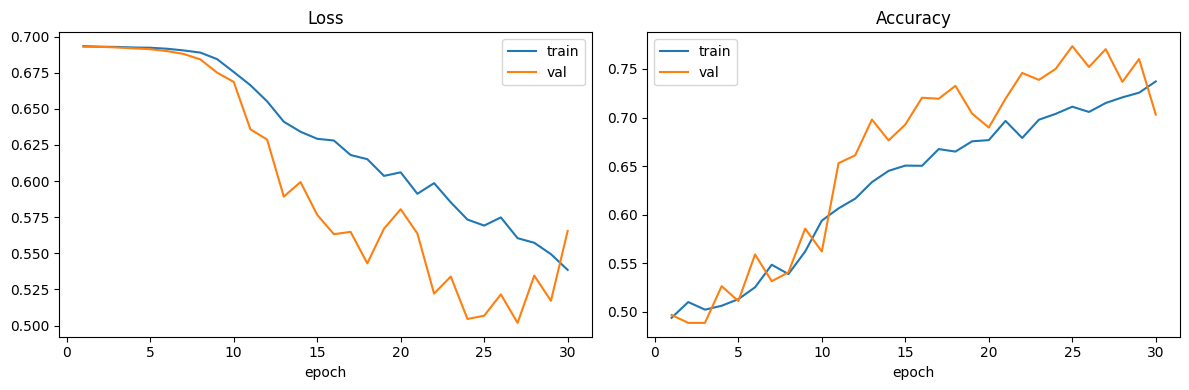

In [37]:
history['train_acc'] = [a.item() if torch.is_tensor(a) else a for a in history['train_acc']]
history['val_acc'] = [a.item() if torch.is_tensor(a) else a for a in history['val_acc']]

epochs = range(1, len(history['train_loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs, history['train_loss'], label='train')
ax[0].plot(epochs, history['val_loss'], label='val')
ax[0].set_title('Loss')
ax[0].set_xlabel('epoch')
ax[0].legend()

ax[1].plot(epochs, history['train_acc'], label='train')
ax[1].plot(epochs, history['val_acc'], label='val')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

#### **구간별 해석**

- **1~8 epoch (정체)**: loss가 0.693 근처에 붙어 있고 정확도는 50% 안팎입니다. 모델이 아직 찍는 수준이고, 교재의 400장 로그와 같은 모습입니다.
- **9~13 epoch (도약)**: loss가 급격히 내려가고(val 0.67 → 약 0.59), 정확도도 같이 크게 오릅니다. 학습이 실제로 시작된 구간입니다.
- **14~30 epoch (완만한 개선)**: train loss는 꾸준히 내려가고(약 0.54까지), train 정확도도 약 74%까지 올라갑니다. val은 출렁이면서 전체적으로 좋아지는 추세입니다.

#### **그래프에서 눈에 띄는 점**

**1. val이 train보다 좋게 나옵니다.** 보통은 반대인데, 훈련 때만 Dropout과 데이터 증강(RandomResizedCrop, 좌우 반전)이 적용되기 때문에 생기는 정상적인 현상입니다. 발표에서 질문이 나올 만한 부분이라 미리 설명해 두면 좋습니다.

**2. val 곡선이 많이 흔들립니다.** 검증 데이터가 980장이라 epoch마다 몇 %p씩 오르내립니다. val 정확도는 25 epoch 부근에서 최고(약 77%)를 찍고, 마지막 30 epoch에서 70%로 떨어졌습니다. val loss도 27 epoch 근처 최저(약 0.50)에서 마지막에 0.565로 올랐습니다.

**3. 이 흔들림이 과적합인지는 이 그래프만으로 단정할 수 없습니다.** 과적합이라면 train 지표는 계속 좋아지는데 val 지표가 꾸준히 나빠져야 하는데, 지금은 마지막 한두 epoch만 나빠졌습니다. train 곡선은 30 epoch까지 계속 올라가고 있어서, 아직 학습이 끝나지 않았다(더 돌리면 좋아질 여지가 있다)는 쪽에 가깝습니다. 다만 마지막 몇 점만으로는 판단이 어려우니 "과적합 징후는 뚜렷하지 않다" 정도로 말하는 게 정확합니다.

#### **발표용 한 줄 요약**

"데이터 5000장으로 처음부터 학습한 AlexNet은 약 8 epoch 동안 정체하다가 9 epoch부터 학습이 시작되었고, 30 epoch 시점에 train 정확도 약 74%, val 정확도 70~77%까지 올랐다. train 지표는 아직 개선 중이라 더 학습하면 좋아질 여지가 있다."

그래프의 최고 val 정확도 지점(약 25 epoch)이 `alexnet_best.pth`에 저장된 모델이라는 점도 같이 말해 두면, 예시 이미지(최고 모델)와 그래프가 어떻게 연결되는지 설명이 됩니다.

In [35]:
model.load_state_dict(torch.load('/content/drive/MyDrive/alexnet_best.pth'))
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [38]:
import pandas as pd
id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})
res.to_csv('/content/alexnet.csv', index=False)

  0%|          | 0/20 [00:00<?, ?it/s]

In [39]:
res.head(20)

,id,label
0,2736,0.295641
1,2022,0.558485
2,2712,0.280349
3,261,0.238680
4,1689,0.619210
5,1217,0.239947
6,1231,0.170391
7,1408,0.607132
8,2651,0.619390
9,1639,0.279412


In [40]:
class_ = classes = {0:'cat', 1:'dog'}

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 10))   # 변경: 세로 6 -> 10
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = res['label'].iloc[i]   # 변경: random.choice 두 줄 대신 i번째 예측값 사용
        if label > 0.5:
            label = 1
        else:
            label = 0

        # 추가: 정답(파일명 기준)과 비교해서 색 지정
        true = 1 if os.path.basename(image_filepath).startswith('dog') else 0
        color = 'green' if label == true else 'red'

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(f'pred: {class_[label]}\ntrue: {class_[true]}', color=color)   # 변경: 제목에 정답 표시
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

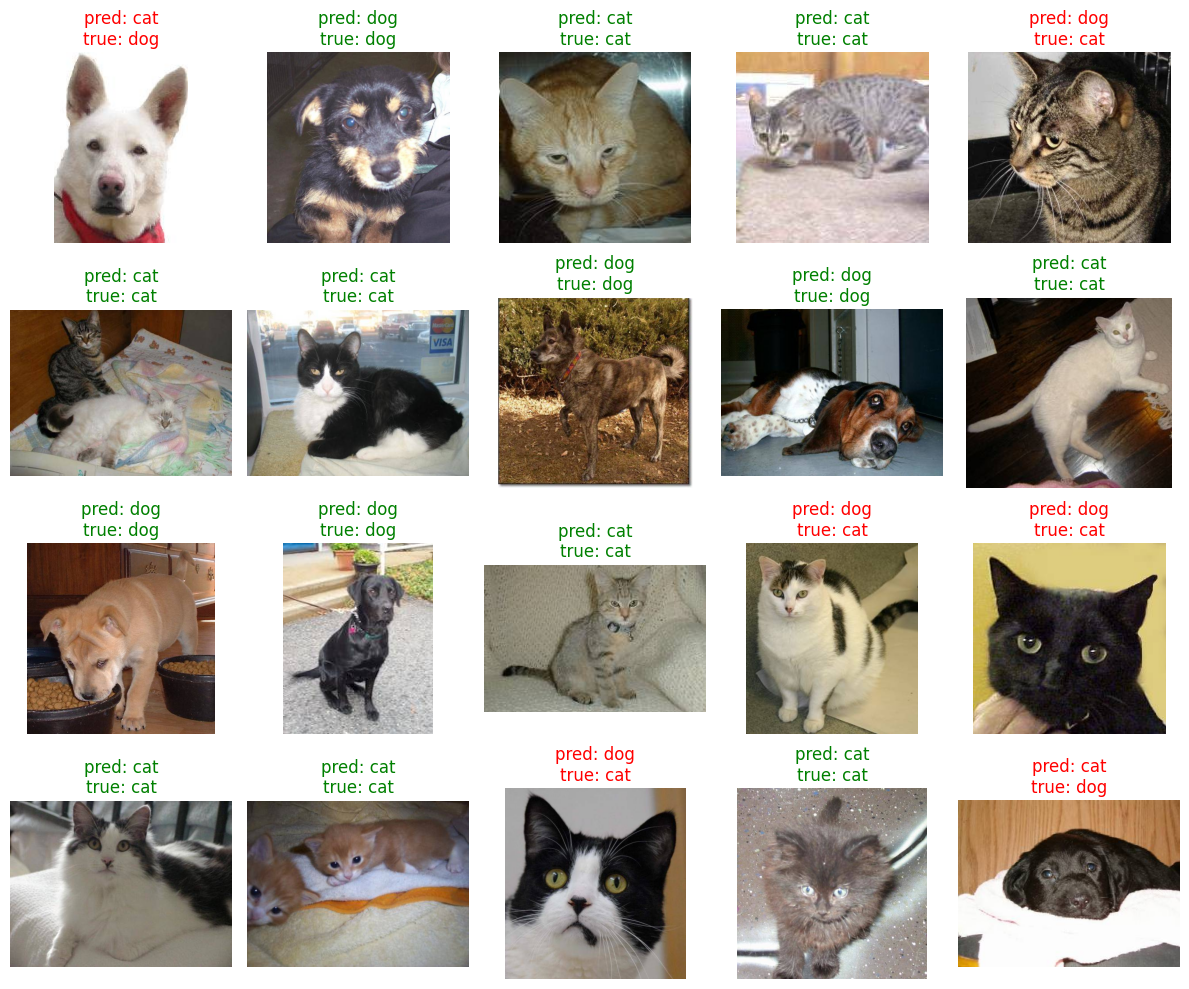

In [42]:
display_image_grid(test_images_filepaths)

In [43]:
true_list = [1 if os.path.basename(p).startswith('dog') else 0 for p in test_images_filepaths]
pred_label = [1 if p > 0.5 else 0 for p in res['label']]
print(sum(t == p for t, p in zip(true_list, pred_label)), '/', len(true_list))

14 / 20
